###### **<span style="font-family: 'Palatino Linotype', serif;"> Iniciação à Pesquisa III </span>**

## **<span style="font-family: 'Palatino Linotype', serif;"> Parte II - Escalonamento do pipeline híbrido Boltz-2 + Machine Learning </span>**

#### **<span style="font-family: 'Palatino Linotype', serif;"> Autor:</span>** <span style="font-family: 'Palatino Linotype', serif;"> Caio M. Leão Dantas</span> 
#### **<span style="font-family: 'Palatino Linotype', serif;"> Orientador:</span>** <span style="font-family: 'Palatino Linotype', serif;"> Leandro Oliveira Bortot</span> 
#### **<span style="font-family: 'Palatino Linotype', serif;"> Agradecimentos:</span>** <span style="font-family: 'Palatino Linotype', serif;"> Guilherme C. de A. Sobreira e Amauri D. Leal Júnior</span> 

___

In [1]:
# pip install numpy pandas matplotlib seaborn scipy scikit-learn optuna rdkit transformers jupyter ipykernel
# pip install torch

In [4]:
from pathlib import Path
import os
import glob
import json
import random
import time
import math
import copy
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from scipy.stats import spearmanr, pearsonr

from transformers import AutoTokenizer, AutoModel

from rdkit import Chem, RDLogger

In [5]:
RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")

In [9]:
REFERENCE_RESULTS_DIR = Path("./predictions/")
REFERENCE_LIBRARY_CSV = Path("./Enamine_PPI_Protein_Mimetics_Library_plated_8960cmpds_20250824.csv")
LARGE_LIBRARY_CSV = Path("./Enamine_Hit_Locator_Library_plated_460160cmpds_20260906.csv")
OUTPUT_DIR = Path("./results_approach_II")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
SEED = 8
TEST_SIZE = 0.15
VAL_SIZE_RELATIVE_TO_REMAINDER = 0.18
BATCH_SIZE_EMBED = 64
BATCH_SIZE_ML = 256
MAX_LENGTH = 128
CHEMBERTA_NAME = "DeepChem/ChemBERTa-77M-MTR"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TARGET_COLUMN = "affinity_probability_binary"

TOP_N_INITIAL = 10_000
TOP_N_FINAL = 1_000

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [11]:
def set_seed(seed=8):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


## Extração do dataset de referência do Boltz-2

Cada subpasta representa um ligante. O objetivo é transformar todos os JSONs produzidos pelo Boltz-2 em uma única tabela. A estrutura final precisa conter, no mínimo, `ID`, `confidence_score`, `ligand_iptm`, `affinity_pred_value` e `affinity_probability_binary`.

In [12]:
def extract_boltz_results(results_dir: Path) -> pd.DataFrame:
    if not results_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {results_dir.resolve()}")

    rows = []
    folders = sorted([p for p in results_dir.iterdir() if p.is_dir()])
    print(f"Pastas encontradas: {len(folders)}")

    for folder in folders:
        ligand_id = folder.name
        row = {"ID": ligand_id}

        confidence_files = sorted(folder.glob("confidence*.json"))
        affinity_files = sorted(folder.glob("affinity*.json"))

        if confidence_files:
            try:
                with open(confidence_files[0], "r", encoding="utf-8") as f:
                    d = json.load(f)
                row["confidence_score"] = d.get("confidence_score")
                row["ligand_iptm"] = d.get("ligand_iptm")
            except Exception as exc:
                print(f"Aviso: erro em confidence de {ligand_id}: {exc}")

        if affinity_files:
            try:
                with open(affinity_files[0], "r", encoding="utf-8") as f:
                    d = json.load(f)
                for key in [
                    "affinity_pred_value",
                    "affinity_pred_value1",
                    "affinity_pred_value2",
                    "affinity_probability_binary",
                    "affinity_probability_binary1",
                    "affinity_probability_binary2",
                ]:
                    row[key] = d.get(key)
            except Exception as exc:
                print(f"Aviso: erro em affinity de {ligand_id}: {exc}")

        rows.append(row)

    return pd.DataFrame(rows)

reference_boltz = extract_boltz_results(REFERENCE_RESULTS_DIR)
reference_boltz.head()


Pastas encontradas: 8902


,ID,confidence_score,ligand_iptm,affinity_pred_value,affinity_pred_value1,affinity_pred_value2,affinity_probability_binary,affinity_probability_binary1,affinity_probability_binary2
0,Z1000025608,0.751624,0.813121,1.184269,1.463360,0.905178,0.092448,0.039319,0.145577
1,Z1002252374,0.741505,0.818983,1.732567,1.565668,1.899466,0.177692,0.204996,0.150388
2,Z1002275380,0.724854,0.799780,1.427589,1.703416,1.151762,0.303021,0.181186,0.424857
3,Z1002413228,0.774738,0.970257,1.787277,2.090669,1.483884,0.252947,0.192844,0.313050
4,Z1002777422,0.774451,0.915325,1.581710,1.251683,1.911738,0.160941,0.111808,0.210073


In [13]:
if not REFERENCE_LIBRARY_CSV.exists():
    raise FileNotFoundError(f"CSV da biblioteca de referência não encontrado: {REFERENCE_LIBRARY_CSV.resolve()}")

library_ref = pd.read_csv(REFERENCE_LIBRARY_CSV, skiprows=1)

# Tentando localizar automaticamente as colunas usuais.
id_candidates = [c for c in library_ref.columns if c.lower() in {"catalog id", "id", "catalog_id"}]
smiles_candidates = [c for c in library_ref.columns if c.lower() == "smiles"]

if not id_candidates or not smiles_candidates:
    raise ValueError(
        "Não foi possível identificar automaticamente as colunas de ID e SMILES. "
        f"Colunas disponíveis: {list(library_ref.columns)}"
    )

ref_id_col = id_candidates[0]
ref_smiles_col = smiles_candidates[0]

library_ref = library_ref[[ref_id_col, ref_smiles_col]].rename(
    columns={ref_id_col: "ID", ref_smiles_col: "SMILES"}
)

reference_df = reference_boltz.merge(library_ref, on="ID", how="inner")

print("Boltz rows:", len(reference_boltz))
print("Library rows:", len(library_ref))
print("Merged rows:", len(reference_df))

if reference_df.empty:
    raise ValueError("O merge resultou em zero moléculas. Verifique os IDs.")

reference_df.to_csv(OUTPUT_DIR / "reference_raw_8960.csv", index=False)
reference_df.head()

Boltz rows: 8902
Library rows: 8960
Merged rows: 8902


,ID,confidence_score,ligand_iptm,affinity_pred_value,affinity_pred_value1,affinity_pred_value2,affinity_probability_binary,affinity_probability_binary1,affinity_probability_binary2,SMILES
0,Z1000025608,0.751624,0.813121,1.184269,1.463360,0.905178,0.092448,0.039319,0.145577,O=C(CC1=CNC=2C=C(F)C=CC12)NCCC(=O)N3CCCCCC3
1,Z1002252374,0.741505,0.818983,1.732567,1.565668,1.899466,0.177692,0.204996,0.150388,COC=1C=CC(=CC1)C2CCN(C2)C3=NC=C(S3)S(N)(=O)=O
2,Z1002275380,0.724854,0.799780,1.427589,1.703416,1.151762,0.303021,0.181186,0.424857,CC(C)N(C(C)C)S(=O)(=O)C=1C=CC(=NC1)N2CCN(CC2)C...
3,Z1002413228,0.774738,0.970257,1.787277,2.090669,1.483884,0.252947,0.192844,0.313050,O=C1NC2(CCC2)C(=O)N1CC3=COC(=N3)C=4C=CC=CC4
4,Z1002777422,0.774451,0.915325,1.581710,1.251683,1.911738,0.160941,0.111808,0.210073,CCC1=NN=C(CN2CCN(CC2)C(=O)C3=CC=4C=CC=CC4N3)N1C


## Controle de qualidade químico

Antes do treinamento, removemos apenas moléculas que não conseguem ser interpretadas como SMILES válidos ou que não possuem o target. O notebook registra quantas moléculas foram removidas para que o tamanho efetivo do dataset seja transparente.

In [14]:
before = len(reference_df)
reference_df = reference_df.drop_duplicates(subset="ID").copy()
reference_df["Mol"] = reference_df["SMILES"].map(Chem.MolFromSmiles)
reference_df["smiles_valid"] = reference_df["Mol"].notna()

numeric_cols = [
    "confidence_score",
    "ligand_iptm",
    "affinity_pred_value",
    "affinity_probability_binary",
]

for c in numeric_cols:
    reference_df[c] = pd.to_numeric(reference_df[c], errors="coerce")

reference_df = reference_df[reference_df["smiles_valid"]].copy()
reference_df = reference_df.dropna(subset=[TARGET_COLUMN]).copy()

print(f"Antes do QC: {before}")
print(f"Depois do QC: {len(reference_df)}")
print(f"SMILES inválidos removidos: {(~reference_df['smiles_valid']).sum() if 'smiles_valid' in reference_df else 'n/a'}")
print(f"Target utilizado: {TARGET_COLUMN}")

reference_df.drop(columns=["Mol"], inplace=True)
reference_df.to_csv(OUTPUT_DIR / "reference_clean_8960.csv", index=False)


Antes do QC: 8902
Depois do QC: 8902
SMILES inválidos removidos: 0
Target utilizado: affinity_probability_binary


                              count      mean       std       min       25%  \
confidence_score             8902.0  0.761531  0.024618  0.651746  0.745486   
ligand_iptm                  8902.0  0.897438  0.050737  0.430850  0.870740   
affinity_pred_value          8902.0  1.263610  0.511963 -0.988362  0.928665   
affinity_probability_binary  8902.0  0.184787  0.088877  0.024598  0.123543   

                                  50%       75%       max  
confidence_score             0.762457  0.778773  0.837516  
ligand_iptm                  0.907508  0.934769  0.982170  
affinity_pred_value          1.280961  1.605166  3.326615  
affinity_probability_binary  0.166696  0.222447  0.690957  


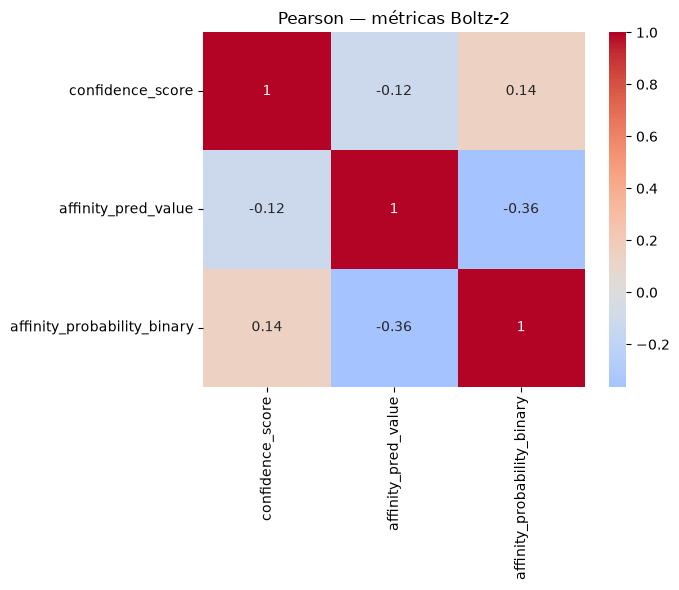

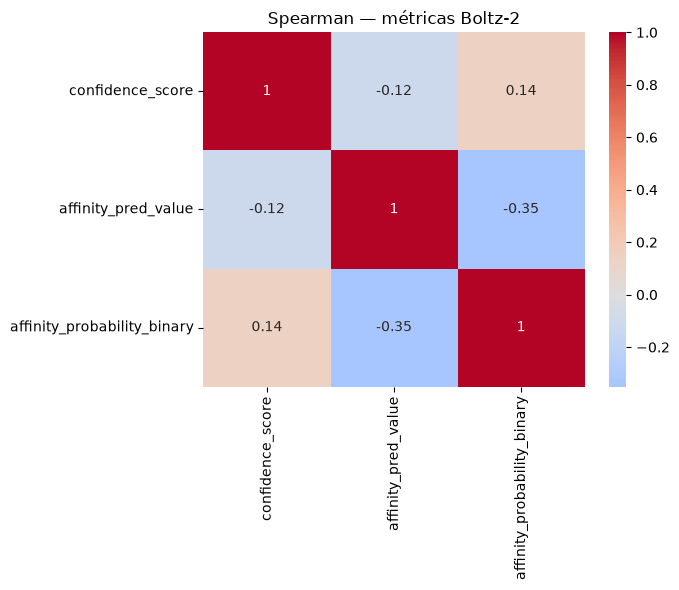

In [15]:
print(reference_df[[
    "confidence_score",
    "ligand_iptm",
    "affinity_pred_value",
    "affinity_probability_binary",
]].describe().T)

corr_pearson = reference_df[[
    "confidence_score",
    "affinity_pred_value",
    "affinity_probability_binary",
]].corr(method="pearson")

corr_spearman = reference_df[[
    "confidence_score",
    "affinity_pred_value",
    "affinity_probability_binary",
]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pearson — métricas Boltz-2")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Spearman — métricas Boltz-2")
plt.tight_layout()
plt.show()


## Split único de treino/validação/teste

O split é definido uma única vez e reutilizado em toda a etapa de treinamento. Para a versão principal, usamos o mesmo princípio do trabalho anterior. O índice do conjunto é salvo em CSV para permitir reprodução exata.

In [16]:
indices = np.arange(len(reference_df))
idx_train_val, idx_test = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
)
idx_train, idx_val = train_test_split(
    idx_train_val,
    test_size=VAL_SIZE_RELATIVE_TO_REMAINDER,
    random_state=SEED,
)

split_label = np.full(len(reference_df), "test", dtype=object)
split_label[idx_train] = "train"
split_label[idx_val] = "validation"
reference_df["split"] = split_label

print(reference_df["split"].value_counts())
reference_df[["ID", "split"]].to_csv(OUTPUT_DIR / "reference_split.csv", index=False)


split
train         6204
validation    1362
test          1336
Name: count, dtype: int64


## ChemBERTa — representação escolhida

Nesta etapa não refazemos a comparação RDKit/fine-tuning da Parte I. Aqui usamos a representação vencedora e a reavaliamos em um conjunto de referência maior.

In [17]:
tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_NAME)
chemberta = AutoModel.from_pretrained(CHEMBERTA_NAME).to(DEVICE)
chemberta.eval()

print("ChemBERTa carregado:", CHEMBERTA_NAME)

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
norm_std                   | UNEXPECTED | 
regression.out_proj.bias   | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ChemBERTa carregado: DeepChem/ChemBERTa-77M-MTR


In [18]:
def masked_mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def generate_embeddings(smiles_list, batch_size=BATCH_SIZE_EMBED):
    embeddings = []

    for start in range(0, len(smiles_list), batch_size):
        batch_smiles = smiles_list[start:start + batch_size]
        encoded = tokenizer(
            batch_smiles,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )

        input_ids = encoded["input_ids"].to(DEVICE)
        attention_mask = encoded["attention_mask"].to(DEVICE)

        with torch.no_grad():
            outputs = chemberta(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            emb = masked_mean_pool(
                outputs.last_hidden_state,
                attention_mask,
            )

        embeddings.append(emb.cpu())

    return torch.cat(embeddings, dim=0)

reference_embeddings = generate_embeddings(reference_df["SMILES"].tolist())
print("Embedding shape:", tuple(reference_embeddings.shape))


Embedding shape: (8902, 384)


## Normalização sem data leakage

O scaler é ajustado **somente no conjunto de treinamento** e posteriormente aplicado à validação, teste e, quando o modelo estiver congelado, às bibliotecas externas.

In [19]:
X_all = reference_embeddings.numpy().astype(np.float32)
y_all = reference_df[TARGET_COLUMN].to_numpy(dtype=np.float32).reshape(-1, 1)

X_train = X_all[idx_train]
X_val = X_all[idx_val]
X_test = X_all[idx_test]

y_train = y_all[idx_train]
y_val = y_all[idx_val]
y_test = y_all[idx_test]

embed_scaler = StandardScaler()
X_train_scaled = embed_scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = embed_scaler.transform(X_val).astype(np.float32)
X_test_scaled = embed_scaler.transform(X_test).astype(np.float32)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(6204, 384) (1362, 384) (1336, 384)


## FC-NN e early stopping

A FC-NN transforma o embedding de 384 dimensões em um único score de screening.

In [20]:
class MLPRegressor(nn.Module):
    def __init__(self, input_size=384, hidden=(256, 128), dropout=0.20):
        super().__init__()
        layers = []
        in_features = input_size
        for units in hidden:
            layers.extend([
                nn.Linear(in_features, units),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
            in_features = units
        layers.append(nn.Linear(in_features, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def make_loader(X, y, batch_size=BATCH_SIZE_ML, shuffle=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    ds = TensorDataset(X_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def fit_model(
    model,
    train_loader,
    val_loader,
    lr=2e-4,
    weight_decay=1e-5,
    epochs=500,
    patience=50,
):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    criterion = nn.MSELoss()

    best_state = None
    best_val = np.inf
    wait = 0
    history = {"train": [], "val": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


In [21]:
train_loader = make_loader(X_train_scaled, y_train, shuffle=True)
val_loader = make_loader(X_val_scaled, y_val, shuffle=False)

a = MLPRegressor(input_size=X_train_scaled.shape[1], hidden=(256, 128), dropout=0.20)
a, history = fit_model(
    a,
    train_loader,
    val_loader,
    lr=2e-4,
    weight_decay=1e-5,
    epochs=500,
    patience=50,
)


In [22]:
def predict_model(model, X, batch_size=BATCH_SIZE_ML):
    model.eval()
    loader = DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=batch_size,
        shuffle=False,
    )
    preds = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds, axis=0).reshape(-1)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    pearson_r, pearson_p = pearsonr(y_true, y_pred)
    spearman_rho, spearman_p = spearmanr(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p,
    }

pred_test = predict_model(a, X_test_scaled)
metrics_test = regression_metrics(y_test, pred_test)
metrics_test


{'MAE': 0.045947685837745667,
 'MSE': 0.004198906477540731,
 'RMSE': np.float64(0.06479896972592027),
 'R2': 0.4638473391532898,
 'Pearson_r': np.float32(0.6855905),
 'Pearson_p': np.float32(0.0),
 'Spearman_rho': np.float64(0.6928967491722327),
 'Spearman_p': np.float64(1.0315470121589943e-191)}

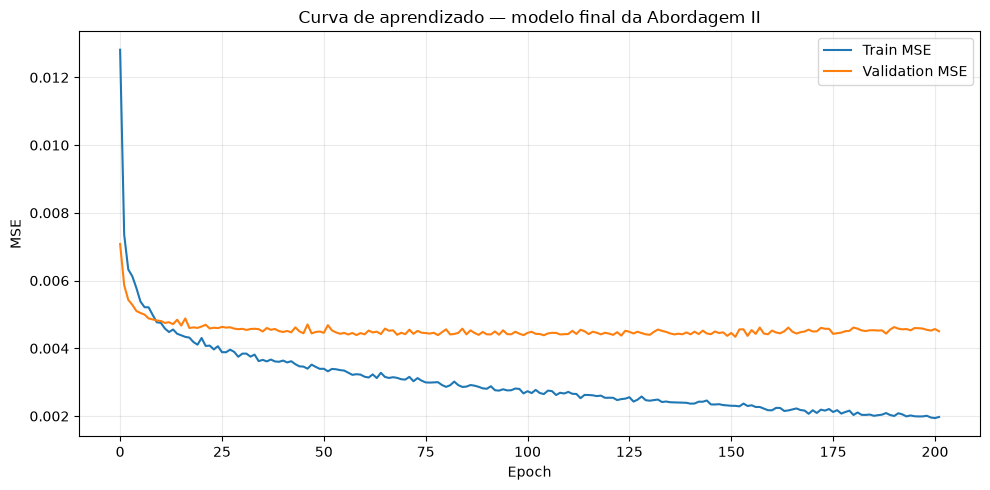

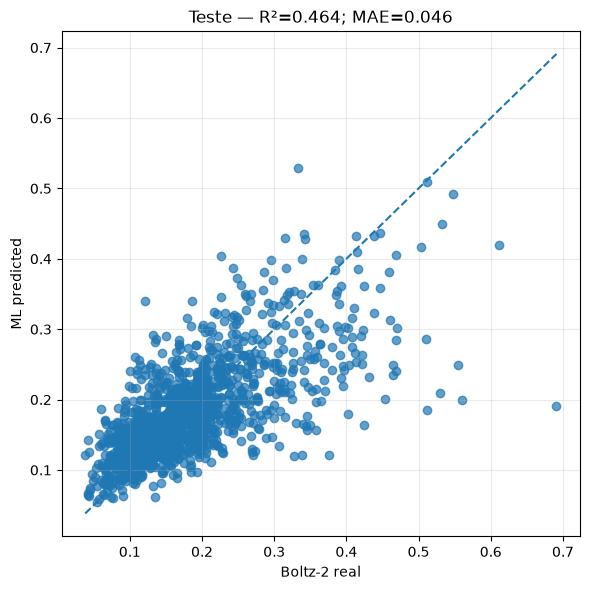

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["train"], label="Train MSE")
ax.plot(history["val"], label="Validation MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Curva de aprendizado — modelo final da Abordagem II")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curve.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test, alpha=0.7)
lo = min(y_test.min(), pred_test.min())
hi = max(y_test.max(), pred_test.max())
ax.plot([lo, hi], [lo, hi], "--")
ax.set_xlabel("Boltz-2 real")
ax.set_ylabel("ML predicted")
ax.set_title(f"Teste — R²={metrics_test['R2']:.3f}; MAE={metrics_test['MAE']:.3f}")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predicted_vs_real_test.png", dpi=300)
plt.show()


## Congelamento do modelo

Depois que o desempenho é considerado satisfatório, esta versão do modelo é congelada. A partir daqui não deve haver novo ajuste de pesos usando a biblioteca grande.

In [24]:
model_path = OUTPUT_DIR / "approach_II_model.pt"
scaler_path = OUTPUT_DIR / "approach_II_embedding_scaler.pkl"
config_path = OUTPUT_DIR / "approach_II_config.json"
metrics_path = OUTPUT_DIR / "approach_II_test_metrics.json"

torch.save(a.state_dict(), model_path)

with open(scaler_path, "wb") as f:
    pickle.dump(embed_scaler, f)

config = {
    "chemberta_name": CHEMBERTA_NAME,
    "max_length": MAX_LENGTH,
    "target_column": TARGET_COLUMN,
    "input_size": int(X_train_scaled.shape[1]),
    "hidden": [256, 128],
    "dropout": 0.20,
    "seed": SEED,
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in metrics_test.items()}, f, indent=2)

print("Modelo salvo em:", model_path)


Modelo salvo em: results_approach_II\approach_II_model.pt


# Benchmark de tempo — inferência ML

Esta seção mede três componentes separadamente:

- **ChemBERTa:** custo de transformar SMILES em embeddings;
- **FC-NN:** custo de prever o score a partir de embeddings já calculados;
- **Pipeline completo:** ChemBERTa + FC-NN.

Para comparações de GPU, a sincronização CUDA é feita antes/depois da região cronometrada.

In [25]:
def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def benchmark_chemberta(smiles_list, batch_size=BATCH_SIZE_EMBED, repeats=3):
    # warm-up
    _ = generate_embeddings(smiles_list[:min(32, len(smiles_list))], batch_size=batch_size)

    times = []
    for _ in range(repeats):
        synchronize()
        t0 = time.perf_counter()
        _ = generate_embeddings(smiles_list, batch_size=batch_size)
        synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), times


def benchmark_mlp(X_scaled, model, batch_size=BATCH_SIZE_ML, repeats=5):
    model.eval()
    tensor = torch.tensor(X_scaled, dtype=torch.float32)
    loader = DataLoader(tensor, batch_size=batch_size, shuffle=False)

    # warm-up
    with torch.no_grad():
        for xb in list(loader)[:1]:
            _ = model(xb.to(DEVICE))

    times = []
    for _ in range(repeats):
        synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            for xb in loader:
                _ = model(xb.to(DEVICE))
        synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), times

# Benchmark em tamanhos progressivos.
benchmark_sizes = [100, 500, 1_000, 5_000]
benchmark_rows = []

smiles_ref = reference_df["SMILES"].tolist()

for n in benchmark_sizes:
    n = min(n, len(smiles_ref))
    smiles_subset = smiles_ref[:n]

    # Embeddings
    t_emb, _ = benchmark_chemberta(smiles_subset)
    emb_subset = generate_embeddings(smiles_subset).numpy().astype(np.float32)
    emb_scaled = embed_scaler.transform(emb_subset).astype(np.float32)

    # MLP
    t_mlp, _ = benchmark_mlp(emb_scaled, a)

    benchmark_rows.append({
        "N": n,
        "ChemBERTa_s": t_emb,
        "MLP_s": t_mlp,
        "Pipeline_s": t_emb + t_mlp,
        "ChemBERTa_mol_s": n / t_emb,
        "Pipeline_mol_s": n / (t_emb + t_mlp),
    })

benchmark_ml_df = pd.DataFrame(benchmark_rows)
benchmark_ml_df.to_csv(OUTPUT_DIR / "benchmark_ml.csv", index=False)
benchmark_ml_df


,N,ChemBERTa_s,MLP_s,Pipeline_s,ChemBERTa_mol_s,Pipeline_mol_s
0,100,0.366344,0.002002,0.368345,272.967559,271.484245
1,500,2.199830,0.006801,2.206631,227.290301,226.589775
2,1000,3.724285,0.010424,3.734709,268.507937,267.758493
3,5000,17.664669,0.056983,17.721652,283.050868,282.140738


## Benchmark de Boltz-2

O notebook não deve presumir um comando específico de execução do Boltz-2, pois isso depende do ambiente/HPC usado no projeto. Por isso, esta seção foi desenhada para receber **tempos reais medidos** em uma amostra de tamanho conhecido pel usuário. A recomendação é medir, no mesmo hardware e com a mesma configuração usada no projeto (por exemplo, 3 Recycling Steps), vários tamanhos de amostra. Depois os tempos podem ser inseridos na tabela abaixo.

No nosso caso, o tempo do Boltz2 não foi revelado vide outros projetos.

In [26]:
boltz_benchmark = pd.DataFrame({
    "N": [100, 500, 1_000],
    "Boltz2_s": [np.nan, np.nan, np.nan],
})

boltz_benchmark["Boltz2_mol_s"] = boltz_benchmark["N"] / boltz_benchmark["Boltz2_s"]
boltz_benchmark.to_csv(OUTPUT_DIR / "benchmark_boltz2.csv", index=False)
boltz_benchmark


,N,Boltz2_s,Boltz2_mol_s
0,100,NaN,NaN
1,500,NaN,NaN
2,1000,NaN,NaN


In [27]:
runtime_comparison = benchmark_ml_df.merge(boltz_benchmark, on="N", how="inner")
runtime_comparison["Speedup_Boltz_vs_ML"] = (
    runtime_comparison["Boltz2_s"] / runtime_comparison["Pipeline_s"]
)
runtime_comparison["ML_fraction_of_Boltz"] = (
    runtime_comparison["Pipeline_s"] / runtime_comparison["Boltz2_s"]
)

runtime_comparison.to_csv(OUTPUT_DIR / "runtime_comparison.csv", index=False)
runtime_comparison


,N,ChemBERTa_s,MLP_s,Pipeline_s,ChemBERTa_mol_s,Pipeline_mol_s,Boltz2_s,Boltz2_mol_s,Speedup_Boltz_vs_ML,ML_fraction_of_Boltz
0,100,0.366344,0.002002,0.368345,272.967559,271.484245,NaN,NaN,NaN,NaN
1,500,2.199830,0.006801,2.206631,227.290301,226.589775,NaN,NaN,NaN,NaN
2,1000,3.724285,0.010424,3.734709,268.507937,267.758493,NaN,NaN,NaN,NaN


In [28]:
LARGE_LIBRARY_SIZE_EXPECTED = 460_160

last_ml = benchmark_ml_df.sort_values("N").iloc[-1]
ml_throughput = float(last_ml["Pipeline_mol_s"])

estimated_ml_seconds = LARGE_LIBRARY_SIZE_EXPECTED / ml_throughput
estimated_ml_hours = estimated_ml_seconds / 3600

print(f"ML throughput: {ml_throughput:.2f} moléculas/s")
print(f"Tempo estimado do ML para {LARGE_LIBRARY_SIZE_EXPECTED:,}: {estimated_ml_hours:.2f} h")

if boltz_benchmark["Boltz2_mol_s"].notna().any():
    valid_boltz = boltz_benchmark.dropna(subset=["Boltz2_mol_s"]).sort_values("N").iloc[-1]
    boltz_throughput = float(valid_boltz["Boltz2_mol_s"])
    estimated_boltz_seconds = LARGE_LIBRARY_SIZE_EXPECTED / boltz_throughput
    print(f"Tempo estimado do Boltz-2 para a mesma biblioteca: {estimated_boltz_seconds/3600:.2f} h")
else:
    print("Boltz-2 ainda não possui benchmark preenchido; não será feita extrapolação.")


ML throughput: 282.14 moléculas/s
Tempo estimado do ML para 460,160: 0.45 h
Boltz-2 ainda não possui benchmark preenchido; não será feita extrapolação.


# Screening da biblioteca grande

Agora entra a parte que será usada para demonstrar a escalabilidade real. O modelo está congelado: não haverá treinamento com os compostos da biblioteca grande.

In [29]:
if not LARGE_LIBRARY_CSV.exists():
    raise FileNotFoundError(f"Biblioteca grande não encontrada: {LARGE_LIBRARY_CSV.resolve()}")

large = pd.read_csv(LARGE_LIBRARY_CSV, skiprows=1)

id_candidates = [c for c in large.columns if c.lower() in {"catalog id", "id", "catalog_id"}]
smiles_candidates = [c for c in large.columns if c.lower() == "smiles"]

if not smiles_candidates:
    raise ValueError(f"Coluna SMILES não encontrada. Colunas: {list(large.columns)}")

large_smiles_col = smiles_candidates[0]
large_id_col = id_candidates[0] if id_candidates else None

if large_id_col:
    large_screen = large[[large_id_col, large_smiles_col]].rename(
        columns={large_id_col: "ID", large_smiles_col: "SMILES"}
    ).copy()
else:
    large_screen = large[[large_smiles_col]].rename(columns={large_smiles_col: "SMILES"}).copy()
    large_screen.insert(0, "ID", np.arange(len(large_screen)))

large_screen = large_screen.drop_duplicates(subset="ID")
large_screen["Mol"] = large_screen["SMILES"].map(Chem.MolFromSmiles)
large_screen = large_screen[large_screen["Mol"].notna()].drop(columns="Mol").reset_index(drop=True)

print("Biblioteca grande — moléculas válidas:", len(large_screen))


Biblioteca grande — moléculas válidas: 460160


In [30]:
# Recarrega o modelo congelado.
model_frozen = MLPRegressor(input_size=384, hidden=(256, 128), dropout=0.20).to(DEVICE)
model_frozen.load_state_dict(torch.load(model_path, map_location=DEVICE))
model_frozen.eval()

def screen_library(df_library, batch_size=BATCH_SIZE_EMBED):
    scores = []
    n = len(df_library)

    synchronize()
    total_start = time.perf_counter()

    for start in range(0, n, batch_size):
        batch_smiles = df_library["SMILES"].iloc[start:start + batch_size].tolist()

        encoded = tokenizer(
            batch_smiles,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        input_ids = encoded["input_ids"].to(DEVICE)
        attention_mask = encoded["attention_mask"].to(DEVICE)

        with torch.no_grad():
            outputs = chemberta(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            emb = masked_mean_pool(outputs.last_hidden_state, attention_mask)
            emb = emb.cpu().numpy().astype(np.float32)

        emb_scaled = embed_scaler.transform(emb).astype(np.float32)
        xb = torch.tensor(emb_scaled, dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            batch_scores = model_frozen(xb).squeeze(1).cpu().numpy()

        scores.append(batch_scores)

        if (start == 0) or ((start + batch_size) % (batch_size * 100) == 0):
            print(f"Processadas: {min(start + batch_size, n):,}/{n:,}")

    synchronize()
    total_time = time.perf_counter() - total_start

    return np.concatenate(scores), total_time

large_scores, total_screen_time = screen_library(large_screen)
large_screen["ML_score"] = large_scores

large_screen.to_csv(OUTPUT_DIR / "large_library_ML_scores.csv", index=False)

throughput = len(large_screen) / total_screen_time
print(f"Tempo total: {total_screen_time:.3f} s")
print(f"Throughput: {throughput:.2f} moléculas/s")
print(f"Throughput: {throughput*60:.2f} moléculas/min")

Processadas: 64/460,160
Processadas: 6,400/460,160
Processadas: 12,800/460,160
Processadas: 19,200/460,160
Processadas: 25,600/460,160
Processadas: 32,000/460,160
Processadas: 38,400/460,160
Processadas: 44,800/460,160
Processadas: 51,200/460,160
Processadas: 57,600/460,160
Processadas: 64,000/460,160
Processadas: 70,400/460,160
Processadas: 76,800/460,160
Processadas: 83,200/460,160
Processadas: 89,600/460,160
Processadas: 96,000/460,160
Processadas: 102,400/460,160
Processadas: 108,800/460,160
Processadas: 115,200/460,160
Processadas: 121,600/460,160
Processadas: 128,000/460,160
Processadas: 134,400/460,160
Processadas: 140,800/460,160
Processadas: 147,200/460,160
Processadas: 153,600/460,160
Processadas: 160,000/460,160
Processadas: 166,400/460,160
Processadas: 172,800/460,160
Processadas: 179,200/460,160
Processadas: 185,600/460,160
Processadas: 192,000/460,160
Processadas: 198,400/460,160
Processadas: 204,800/460,160
Processadas: 211,200/460,160
Processadas: 217,600/460,160
Proces

In [31]:
top10k = (
    large_screen.sort_values("ML_score", ascending=False)
    .head(min(TOP_N_INITIAL, len(large_screen)))
    .reset_index(drop=True)
)

top10k.to_csv(OUTPUT_DIR / "top_10000_ML.csv", index=False)
print(top10k[["ID", "SMILES", "ML_score"]].head(20))


             ID                                             SMILES  ML_score
0     Z68708958       O=C(CNC(=O)C1=CC=CS1)NC2=NC(=CS2)C=3C=CC=CN3  0.632518
1    Z735230392   O=C(NC=1C=CC=C2C=CC=NC12)C=3C=C(Cl)C=C4C=CC=NC34  0.613202
2    Z406392720  O=C1NC2(CCOC=3C=CC=CC32)C(=O)N1CC4=CC=C(Cl)C5=...  0.587675
3    Z238302104  CN(C(=O)C1=CC=C(NC(=O)C2=CC=CO2)S1)C3=NC=4C=CC...  0.585422
4     Z28307187                O=C(NC1=NC(=CS1)C2=CC=CS2)C3=CC=CO3  0.570040
5     Z96004047            O=C(NC1=NC(=CS1)C2=CC=C(Br)S2)C3=CC=CO3  0.568045
6     Z29651530        O=C(NC1=NC(=CS1)C2=CNC=3C=CC=CC23)C4=CC=CS4  0.567803
7   Z1038145536   CC1=CC=C(NC(=O)C2=CNC=3C=CC=CC3C2=O)C4=CC=CN=C14  0.563487
8     Z28307280            O=C(NC1=NC(=CS1)C2=CC=CS2)C3=CC=C(Br)O3  0.561977
9     Z57745168   O=S(=O)(NC=1C=CC=C2C=CC=NC12)C=3C=CC=C4C=CC=NC34  0.559405
10  Z1070219674  O=C(C=1C=CC=C(C1)N2C(=O)C=3C=CC=CC3C2=O)N4CCC(...  0.554789
11    Z29467696              O=C(NC1=NC(=CS1)C=2C=CC=CN2)C3=CC=CS3  0.554496

# Seleção do Top-1.000

A seleção abaixo é deliberadamente simples e transparente: primeiro ordenamos pelo score do ML.

In [32]:
top1000 = top10k.head(min(TOP_N_FINAL, len(top10k))).copy()
top1000.to_csv(OUTPUT_DIR / "top_1000_ML_for_Boltz2.csv", index=False)

print(f"Top-1.000 selecionado: {len(top1000):,}")
print("Redução relativa da biblioteca:", f"{len(large_screen)/len(top1000):.1f}x")


Top-1.000 selecionado: 1,000
Redução relativa da biblioteca: 460.2x


In [33]:
summary = pd.DataFrame({
    "quantity": [
        "Large library size",
        "Top-10k",
        "Top-1k",
        "Reduction to Top-1k",
        "ML runtime (s)",
        "ML throughput (mol/s)",
    ],
    "value": [
        len(large_screen),
        len(top10k),
        len(top1000),
        len(large_screen) / len(top1000),
        total_screen_time,
        throughput,
    ]
})

summary.to_csv(OUTPUT_DIR / "approach_II_scalability_summary.csv", index=False)
summary


,quantity,value
0,Large library size,460160.000000
1,Top-10k,10000.000000
2,Top-1k,1000.000000
3,Reduction to Top-1k,460.160000
4,ML runtime (s),2048.769532
5,ML throughput (mol/s),224.603106
